# Stock Market Analysis using Python

## Objective

The objective of this project is to analyze the historical stock price of Reliance Industries using Python. The project downloads stock data from Yahoo Finance, calculates technical indicators such as moving averages and daily returns, visualizes stock price trends, and interprets the results to understand the market trend.


## Technologies Used

- Python
- Pandas
- yfinance
- Matplotlib
- Jupyter Notebook

## Project Workflow

1. Import required libraries.
2. Download historical stock data using Yahoo Finance.
3. Explore the dataset.
4. Calculate 20-day and 50-day Moving Averages.
5. Compute Daily Returns.
6. Generate Buy/Sell signals using Moving Average crossover.
7. Visualize stock price and moving averages.
8. Draw conclusions from the analysis.

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully!")


Libraries imported successfully!


## Download Historical Stock Data

In [2]:
stock = yf.download(
    "RELIANCE.NS",
    start="2024-01-01",
    end="2025-01-01"
)

stock.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2024-01-01,1279.692871,1287.894020,1271.244701,1274.900686,4030540
2024-01-02,1290.290039,1291.920403,1271.170629,1277.099136,7448800
2024-01-03,1276.259277,1301.307194,1273.245572,1289.450180,9037536
2024-01-04,1282.854736,1289.376190,1274.184391,1278.581319,9612778
2024-01-05,1288.313843,1294.316528,1283.521657,1285.942416,8086406


## Dataset Description

The downloaded dataset contains:

- Open Price
- High Price
- Low Price
- Close Price
- Volume

These values represent the daily trading information of Reliance Industries.

# Moving Average Analysis

We calculate two moving averages:

- 20-Day Moving Average (Short-term trend)
- 50-Day Moving Average (Long-term trend)

If the 20-day moving average is above the 50-day moving average, it indicates a bullish trend.

If the 20-day moving average is below the 50-day moving average, it indicates a bearish trend.

In [3]:
stock["MA20"] = stock[("Close","RELIANCE.NS")].rolling(20).mean()

stock["MA50"] = stock[("Close","RELIANCE.NS")].rolling(50).mean()

stock[["MA20","MA50"]].tail()

Price,MA20,MA50
Ticker,,
Date,,
2024-12-24,1262.735083,1285.481133
2024-12-26,1258.935400,1282.388342
2024-12-27,1256.469202,1279.949902
2024-12-30,1252.429089,1277.106953
2024-12-31,1247.784198,1274.311592


# Daily Returns

Daily Return measures the percentage change in stock price compared to the previous trading day.

Positive value → stock gained

Negative value → stock lost

In [4]:
stock["Daily Return"] = stock[("Close","RELIANCE.NS")].pct_change()

stock["Daily Return"].describe()

count    245.000000
mean      -0.000141
std        0.014455
min       -0.074851
25%       -0.008398
50%        0.000310
75%        0.007477
max        0.070192
Name: Daily Return, dtype: float64

# Trading Signal

A simple Moving Average Crossover strategy is used.

Signal = 1 → Buy

Signal = -1 → Sell

In [5]:
stock["Signal"] = 0

stock.loc[stock["MA20"] > stock["MA50"], "Signal"] = 1

stock.loc[stock["MA20"] < stock["MA50"], "Signal"] = -1

stock[["MA20","MA50","Signal"]].tail(15)

Price,MA20,MA50,Signal
Ticker,,,
Date,,,
2024-12-10,1271.583636,1318.898538,-1
2024-12-11,1271.856287,1313.981499,-1
2024-12-12,1271.293646,1309.744590,-1
2024-12-13,1272.324738,1305.937964,-1
2024-12-16,1272.359436,1303.188210,-1
2024-12-17,1271.593555,1300.387896,-1
2024-12-18,1272.168591,1298.058511,-1
2024-12-19,1272.537903,1294.749089,-1


# Stock Price Visualization

The following graph compares:

- Closing Price
- 20-Day Moving Average
- 50-Day Moving Average

The moving averages help identify the market trend.

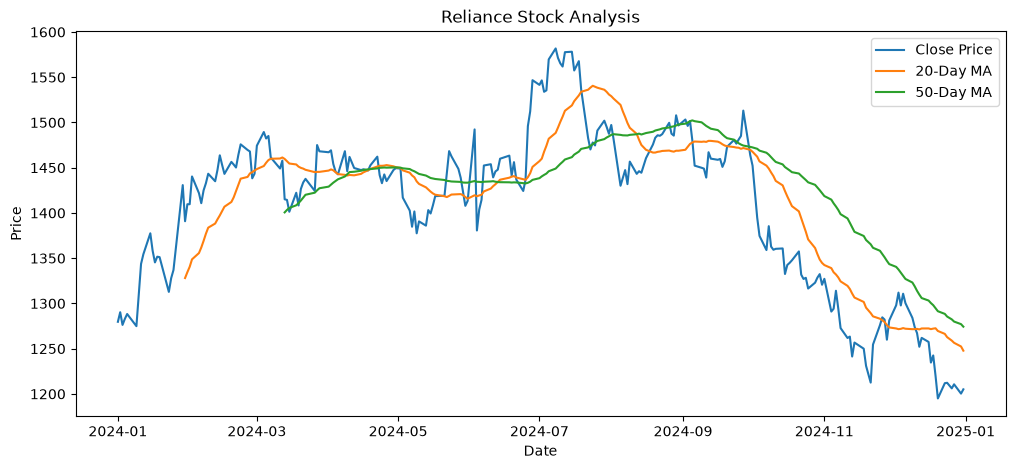

In [6]:
plt.figure(figsize=(12,5))

plt.plot(stock[("Close","RELIANCE.NS")], label="Close Price")
plt.plot(stock["MA20"], label="20-Day MA")
plt.plot(stock["MA50"], label="50-Day MA")

plt.title("Reliance Stock Analysis")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()

plt.show()

# Conclusion

The analysis of Reliance Industries' historical stock data shows how Python can be used to perform basic financial analysis.

Key findings:

- The 20-day and 50-day moving averages successfully identify trend changes.
- Daily returns help measure stock volatility.
- The Moving Average crossover strategy provides simple buy and sell signals.
- Data visualization makes market trends easier to understand.

Future Improvements:

- Analyze multiple stocks simultaneously.
- Add technical indicators like RSI and MACD.
- Build an interactive dashboard using Streamlit.
- Predict future prices using Machine Learning models.
